In [ ]:
from dask.distributed import Client

client = Client(threads_per_worker=1)
client

/Users/u1166368/scratch/virtualizarr/.pixi/envs/default/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 50832 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:50832/status,
Dashboard: http://127.0.0.1:50832/status,Workers: 11
Total threads: 11,Total memory: 18.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:50833,Workers: 0
Dashboard: http://127.0.0.1:50832/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:50864,Total threads: 1
Dashboard: http://127.0.0.1:50865/status,Memory: 1.64 GiB
Nanny: tcp://127.0.0.1:50836,


2026-03-09 05:12:40,964 - distributed.scheduler - WARNING - Worker failed to heartbeat for 993s; attempting restart: <WorkerState 'tcp://127.0.0.1:50870', name: 4, status: running, memory: 0, processing: 0>
2026-03-09 05:12:40,971 - distributed.scheduler - WARNING - Worker failed to heartbeat for 993s; attempting restart: <WorkerState 'tcp://127.0.0.1:50873', name: 2, status: running, memory: 0, processing: 0>
2026-03-09 05:12:40,971 - distributed.scheduler - WARNING - Worker failed to heartbeat for 993s; attempting restart: <WorkerState 'tcp://127.0.0.1:50876', name: 7, status: running, memory: 0, processing: 0>
2026-03-09 05:12:40,971 - distributed.scheduler - WARNING - Worker failed to heartbeat for 993s; attempting restart: <WorkerState 'tcp://127.0.0.1:50879', name: 1, status: running, memory: 0, processing: 0>
2026-03-09 05:12:40,972 - distributed.scheduler - WARNING - Worker failed to heartbeat for 993s; attempting restart: <WorkerState 'tcp://127.0.0.1:50882', name: 8, status: 

In [ ]:
import warnings
import os
import xarray as xr
from virtualizarr import open_virtual_dataset, open_virtual_mfdataset
from virtualizarr.parsers import HDFParser
from obstore.store import S3Store
from obspec_utils.registry import ObjectStoreRegistry

import numcodecs.zarr3  # Register the zarr3 codec

from dotenv import load_dotenv

load_dotenv()

access_key_id = os.environ.get("ACCESS_KEY_ID")
secret_access_key = os.environ.get("SECRET_ACCESS_KEY")
endpoint = "https://projects.pawsey.org.au"
bucket = "s3://1deg"

# create s3 store with aws-style credentials
store = S3Store.from_url(
    f"{bucket}",
    endpoint=endpoint,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
)

registry = ObjectStoreRegistry({f"{bucket}": store})

warnings.filterwarnings(
    "ignore",
    message="Numcodecs codecs are not in the Zarr version 3 specification*",
    category=UserWarning,
)
parser = HDFParser()

We now have proof that we can open that netcdf with virtualizarr. Let's now try opening the entire contents of that bucket as a single virtual dataset.

Following that, we'll try to save it via icechunk

In [2]:
import obstore

flist = []
for batch in obstore.list(store):
    for obj in batch:
        if not obj.get("path","icechunk").startswith("icechunk"):
            flist.append(obj.get("path"))

print(flist)

['output1830/ocean_year.nc', 'output1831/ocean_year.nc', 'output1832/ocean_year.nc', 'output1833/ocean_year.nc', 'output1834/ocean_year.nc', 'output1835/ocean_year.nc', 'output1836/ocean_year.nc', 'output1837/ocean_year.nc', 'output1838/ocean_year.nc', 'output1839/ocean_year.nc', 'output1840/ocean_year.nc', 'output1841/ocean_year.nc', 'output1842/ocean_year.nc', 'output1843/ocean_year.nc', 'output1844/ocean_year.nc', 'output1845/ocean_year.nc', 'output1846/ocean_year.nc', 'output1847/ocean_year.nc', 'output1848/ocean_year.nc', 'output1849/ocean_year.nc', 'output1850/ocean_year.nc', 'output1851/ocean_year.nc', 'output1852/ocean_year.nc', 'output1853/ocean_year.nc', 'output1854/ocean_year.nc', 'output1855/ocean_year.nc', 'output1856/ocean_year.nc', 'output1857/ocean_year.nc', 'output1858/ocean_year.nc', 'output1859/ocean_year.nc', 'output1860/ocean_year.nc', 'output1861/ocean_year.nc', 'output1862/ocean_year.nc', 'output1863/ocean_year.nc', 'output1864/ocean_year.nc', 'output1865/ocean_y

In [11]:
vds = open_virtual_dataset(
    url=f"{bucket}/{flist[0]}",
    parser=parser,
    registry=registry,
    drop_variables=["salt","temp","age_global"]
)

/Users/u1166368/scratch/virtualizarr/.pixi/envs/default/lib/python3.14/site-packages/virtualizarr/xarray.py:343: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  with xr.open_zarr(
/Users/u1166368/scratch/virtualizarr/.pixi/envs/default/lib/python3.14/site-packages/virtualizarr/xarray.py:343: FutureWarning: In a future version, xarray will not decode the variable 'time_bounds' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead

In [12]:
vds

<xarray.Dataset> Size: 2MB
Dimensions:         (xt_ocean: 360, yt_ocean: 300, st_ocean: 50,
                     st_edges_ocean: 51, time: 1, nv: 2)
Coordinates:
  * xt_ocean        (xt_ocean) float64 3kB -279.5 -278.5 -277.5 ... 78.5 79.5
  * yt_ocean        (yt_ocean) float64 2kB -77.88 -77.63 -77.38 ... 89.32 89.77
  * st_ocean        (st_ocean) float64 400B 1.152 3.649 ... 5.034e+03 5.254e+03
  * st_edges_ocean  (st_edges_ocean) float64 408B 0.0 2.303 ... 5.363e+03
  * time            (time) datetime64[ns] 8B 1958-06-30T12:00:00
  * nv              (nv) float64 16B 1.0 2.0
Data variables:
    sst             (time, yt_ocean, xt_ocean) float32 432kB ManifestArray<sh...
    sss             (time, yt_ocean, xt_ocean) float32 432kB ManifestArray<sh...
    mld             (time, yt_ocean, xt_ocean) float32 432kB ManifestArray<sh...
    sea_level       (time, yt_ocean, xt_ocean) float32 432kB ManifestArray<sh...
    average_T1      (time) float64 8B ManifestArray<shape=(1,), dtype=float64...
    average_T2      (time) float64 8B ManifestArray<shape=(1,), dtype=float64...
    average_DT      (time) float64 8B ManifestArray<shape=(1,), dtype=float64...
    time_bounds     (time, nv) float64 16B ManifestArray<shape=(1, 2), dtype=...
Attributes:
    filename:   ocean_year.nc
    title:      ACCESS-OM2-BGC
    grid_type:  mosaic
    grid_tile:  1

In [14]:
combined_vds = open_virtual_mfdataset(
    urls=[f"{bucket}/{f}" for f in flist[1:]],
    parser=parser,
    registry=registry,
    combine="nested",
    concat_dim="time",
    parallel="dask",
    compat="override",
    coords="minimal",
    drop_variables=["salt","temp","age_global","st_edges_ocean","st_ocean",
                    "nv","average_T1","average_T2","average_DT",]
)

/Users/u1166368/scratch/virtualizarr/.pixi/envs/default/lib/python3.14/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/Users/u1166368/scratch/virtualizarr/.pixi/envs/default/lib/python3.14/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/Users/u1166368/scratch/virtualizarr/.pixi/envs/default/lib/python3.14/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/Users/u1166368/scratch/virtualizarr/.pixi/envs/default/lib/python3.14/site-packages/zarr/codecs/numcodecs/_codecs.py:141: Z

In [15]:
# Copied from `~/scratch/virtualizarr/test_nb.ipynb`
# Just using to save the combined virtual dataset as a zarr via icechunk, so we
# don't have to fetch it from pawsey to rebuild it there if something crashes
import xarray as xr
import icechunk
from pathlib import Path

if Path("/Users/u1166368/scratch/virtualizarr/pawsey/1deg").exists():
    import shutil
    shutil.rmtree("/Users/u1166368/scratch/virtualizarr/pawsey/1deg")

# Create a new repository instance with virtual chunk container permissions for reading
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{bucket}/",
        store=icechunk.s3_store(
            endpoint_url=endpoint,              # "https://projects.pawsey.org.au"
            s3_compatible=True,
            force_path_style=True,
        )
    ),
)

# credentials = icechunk.containers_credentials(
#     { "s3://my_s3_bucket": icechunk.s3_credentials(bucket="my-s3-bucket", region="us-east-1"),
#       "s3://my_other_s3_bucket": icechunk.s3_credentials(bucket="my-other-s3-bucket", region="us-west-2"),
#     }
# )

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

# Open the repository with the config that includes virtual chunk permissions
storage = icechunk.local_filesystem_storage("/Users/u1166368/scratch/virtualizarr/pawsey/1deg")
repo = icechunk.Repository.create(storage, config, authorize_virtual_chunk_access=credentials)

# Write your virtual dataset to the repository
write_session = repo.writable_session("main")
combined_vds.vz.to_icechunk(write_session.store)
write_session.commit("Write Pawsey 0deg virtual dataset to local zarr store for testing")

  2026-03-08T08:17:43.361870Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:81



'60ASCM5YX4JD5CE0MN70'

In [ ]:
import xarray as xr
import icechunk
from pathlib import Path

# Create a new repository instance with virtual chunk container permissions for reading
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{bucket}/",
        store=icechunk.s3_store(
            endpoint_url=endpoint,              # "https://projects.pawsey.org.au"
            s3_compatible=True,
            force_path_style=True,
        )
    ),
)

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

# Open the repository with the config that includes virtual chunk permissions
storage = icechunk.local_filesystem_storage("/Users/u1166368/scratch/virtualizarr/pawsey/01deg")
repo = icechunk.Repository.open(storage, config, authorize_virtual_chunk_access=credentials)

# Write your virtual dataset to the repository
session = repo.readonly_session("main")
xr.open_zarr(session.store, consolidated=False)['sst_m'].isel(time=0).plot()

In [ ]:
import matplotlib.pyplot as plt
_arr = xr.open_zarr(session.store, consolidated=False)['sst_m'].data.blocks[0,0,0].compute().squeeze()
plt.pcolor(_arr)

In [17]:
# Now put the virtual dataset in the bucket alongside the netcdf files
import xarray as xr
import icechunk
from pathlib import Path

# Create a new repository instance with virtual chunk container permissions for reading
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{bucket}/",
        store=icechunk.s3_store(
            endpoint_url=endpoint,              # "https://projects.pawsey.org.au"
            s3_compatible=True,
            force_path_style=True,
        )
    ),
)

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

# Open the repository with the config that includes virtual chunk permissions
storage = icechunk.s3_storage(
    bucket='1deg',
    prefix='icechunk',
    endpoint_url=endpoint,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    force_path_style=True,
)
repo = icechunk.Repository.create(storage, config, authorize_virtual_chunk_access=credentials)

# Write your virtual dataset to the repository
write_session = repo.writable_session("main")
combined_vds.vz.to_icechunk(write_session.store)
write_session.commit("Write Pawsey 1deg virtual dataset to pawsey icechunk store for testing")

  2026-03-08T08:18:19.329242Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



'XJBE2W2ZD8JHRWWYCNPG'

In [ ]:
from dask.distributed import Client

client = Client(threads_per_worker=1)
client

In [3]:
import icechunk
from dotenv import load_dotenv
load_dotenv()

access_key_id = os.environ.get("ACCESS_KEY_ID")
secret_access_key = os.environ.get("SECRET_ACCESS_KEY")

endpoint = "https://projects.pawsey.org.au"
bucket = "s3://1deg"

storage = icechunk.s3_storage(
    bucket='1deg',
    prefix='icechunk',
    endpoint_url=endpoint,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    force_path_style=True,
)

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

repo = icechunk.Repository.open(storage=storage, config=None, authorize_virtual_chunk_access=credentials)

session = repo.readonly_session("main")

  2026-03-12T01:38:16.242775Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



/var/folders/qg/vhg6q9gn4zl01xbg1mfw6jzhxzf1wt/T/ipykernel_43511/893728626.py:4: FutureWarning: In a future version, xarray will not decode the variable 'time_bounds' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  _arr = xr.open_zarr(session.store, consolidated=False)['sst'].data.blocks[0,0,0].compute().squeeze()


  2026-03-12T01:38:19.978950Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: io error: client error (Connect): tcp connect error: Host is down (os error 64) (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Io, source: hyper_util::client::legacy::Error(Connect, ConnectError("tcp connect error", 169.254.169.254:80, Os { code: 64, kind: Uncategorized, message: "Host is down" })), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



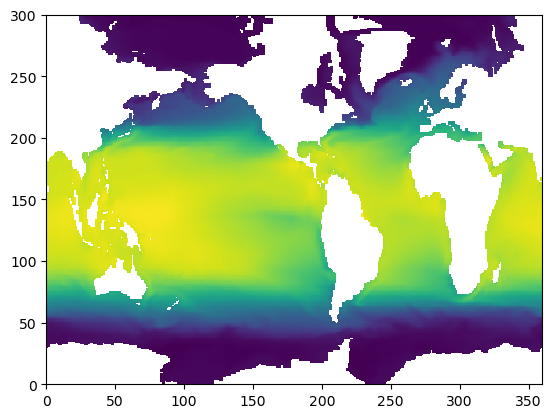

In [4]:
import matplotlib.pyplot as plt
import xarray as xr

_arr = xr.open_zarr(session.store, consolidated=False)['sst'].data.blocks[0,0,0].compute().squeeze()
plt.pcolor(_arr)

In [27]:
xr.open_zarr(session.store, consolidated=False)

/var/folders/qg/vhg6q9gn4zl01xbg1mfw6jzhxzf1wt/T/ipykernel_12952/3705496493.py:1: FutureWarning: In a future version, xarray will not decode the variable 'time_bounds' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  xr.open_zarr(session.store, consolidated=False)


<xarray.Dataset> Size: 104MB
Dimensions:      (time: 60, yt_ocean: 300, xt_ocean: 360, nv: 2)
Coordinates:
  * time         (time) datetime64[ns] 480B 1959-06-30T12:00:00 ... 2018-06-3...
  * yt_ocean     (yt_ocean) float64 2kB -77.88 -77.63 -77.38 ... 89.32 89.77
  * xt_ocean     (xt_ocean) float64 3kB -279.5 -278.5 -277.5 ... 77.5 78.5 79.5
Dimensions without coordinates: nv
Data variables:
    mld          (time, yt_ocean, xt_ocean) float32 26MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    sss          (time, yt_ocean, xt_ocean) float32 26MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    sea_level    (time, yt_ocean, xt_ocean) float32 26MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    sst          (time, yt_ocean, xt_ocean) float32 26MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    time_bounds  (time, nv) timedelta64[ns] 960B dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes:
    filename:   ocean_year.nc
    title:      ACCESS-OM2-BGC
    grid_type:  mosaic
    grid_tile:  1

In [32]:
%%timeit
da = xr.open_zarr(session.store, consolidated=False)['sst'].isel(time=0).compute()
#da.plot()

<magic-timeit>:1: FutureWarning: In a future version, xarray will not decode the variable 'time_bounds' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.


  2026-03-08T08:26:56.289923Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66

  2026-03-08T08:26:57.528222Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorE

<magic-timeit>:1: FutureWarning: In a future version, xarray will not decode the variable 'time_bounds' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.


  2026-03-08T08:26:58.931657Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66

  2026-03-08T08:27:00.168575Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorE

<magic-timeit>:1: FutureWarning: In a future version, xarray will not decode the variable 'time_bounds' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.


...

<magic-timeit>:1: FutureWarning: In a future version, xarray will not decode the variable 'time_bounds' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.


  2026-03-08T08:27:03.117896Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: io error: client error (Connect): tcp connect error: Host is down (os error 64) (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Io, source: hyper_util::client::legacy::Error(Connect, ConnectError("tcp connect error", 169.254.169.254:80, Os { code: 64, kind: Uncategorized, message: "Host is down" })), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66

  2026-03-08T08:27:03.353436Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: io error: client error (Connect): tcp connect error: Host is down (os error 64) (FailedToLoadToken(FailedToLoadToken { source: Di

<magic-timeit>:1: FutureWarning: In a future version, xarray will not decode the variable 'time_bounds' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.


  2026-03-08T08:27:03.752969Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: io error: client error (Connect): tcp connect error: Host is down (os error 64) (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Io, source: hyper_util::client::legacy::Error(Connect, ConnectError("tcp connect error", 169.254.169.254:80, Os { code: 64, kind: Uncategorized, message: "Host is down" })), connection: Unknown } }) }))
    at /Users/runner/miniforge3/conda-bld/icechunk_1772465843790/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66

  2026-03-08T08:27:03.987089Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: io error: client error (Connect): tcp connect error: Host is down (os error 64) (FailedToLoadToken(FailedToLoadToken { source: Di

2026-03-09 05:12:41,007 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/Users/u1166368/scratch/virtualizarr/.pixi/envs/default/lib/python3.14/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/u1166368/scratch/virtualizarr/.pixi/envs/default/lib/python3.14/site-packages/distributed/worker.py", line 1273, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
    ...<14 lines>...
    )
    ^
  File "/Users/u1166368/scratch/virtualizarr/.pixi/envs/default/lib/python3.14/site-packages/distributed/utils_comm.py", line 416, in retry_operation
    return await retry(
   